# Tutorial: Makemore Part 1 Bigram 中文详细教程

Audience:
- 已经学过一点 Python，但还不熟悉 PyTorch 和字符级语言模型的人
- 想把 Karpathy `makemore_part1_bigrams.ipynb` 从“能跑”变成“真正看懂”的读者

Prerequisites:
- 会读 Python 的 `for` 循环、列表、字典
- 知道概率的基本概念，但不要求学过机器学习

Learning goals:
- 看懂 bigram 计数模型是怎么建立的
- 看懂 `stoi / itos / N / P / xs / ys / xenc / W` 各自代表什么
- 看懂负对数似然、one-hot、softmax、梯度下降在这个例子里的具体含义
- 能独立从头重写一个字符级 bigram 模型


## Notebook 导读

这份 notebook 以官方 `Zero2Hero/offcial/makemore_part1_bigrams.ipynb` 为主线，但不直接照抄原来的 cell 粒度。

这里会做三件事：
1. 按原始逻辑顺序完整重走一遍 bigram notebook。
2. 把大 cell 拆细，每一步都说明“为什么要做”和“结果应该怎么看”。
3. 对第一次出现的特殊函数、语法和张量 shape 做显式解释。

你会看到标题里写着“对应原 notebook 的 cell xx-yy”，这是为了帮助你和官方版本对照阅读。


## 章节目录

1. 环境与数据路径
2. 从名字数据里统计 bigram
3. 用 tensor 构造 bigram 计数矩阵 `N`
4. 从计数变成概率，并用概率采样新名字
5. 用负对数似然评估 bigram 模型
6. 把 bigram 写成一个单层神经网络
7. 用自动求导和梯度下降训练网络
8. 对比“统计计数版”和“神经网络版”其实在学同一件事


## Step 0 - 先解决路径问题（对应原 notebook 的数据读取准备）

**这个 cell 做什么**
- 导入本 notebook 后面会用到的基础模块。
- 自动定位 `Zero2Hero/offcial/names.txt`，避免像官方 notebook 一样写死绝对路径。

**输入 / 输出**
- 输入是当前 notebook 的工作目录 `Path.cwd()`。
- 输出会显示解析出的 `ZERO2HERO_DIR` 和 `DATA_PATH`。

**为什么必要**
- 如果你从仓库根目录启动 notebook，路径和从 `Zero2Hero` 目录启动 notebook 不一样。
- 后面所有数据读取都依赖这个路径定位结果。

**特殊函数说明**
- `Path.cwd()`：返回当前工作目录。
- `Path.parents`：沿着父目录逐层向上找。
- 函数定义 `def ...:`：把一段逻辑封装起来，后面可以重复调用。


In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt

%matplotlib inline


def resolve_zero2hero_dir(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if candidate.name == "Zero2Hero" and (candidate / "offcial" / "names.txt").exists():
            return candidate
        if (candidate / "Zero2Hero" / "offcial" / "names.txt").exists():
            return candidate / "Zero2Hero"
    raise FileNotFoundError("无法自动定位 Zero2Hero/offcial/names.txt")


ZERO2HERO_DIR = resolve_zero2hero_dir(Path.cwd().resolve())
DATA_PATH = ZERO2HERO_DIR / "offcial" / "names.txt"

ZERO2HERO_DIR, DATA_PATH


(PosixPath('/Users/wangzhijie/Documents/GitHub/DeepL/Zero2Hero'),
 PosixPath('/Users/wangzhijie/Documents/GitHub/DeepL/Zero2Hero/offcial/names.txt'))

## Step 1 - 读取原始名字数据（对应原 notebook cell 0）

**这个 cell 做什么**
- 从 `names.txt` 读取所有名字。
- 把每一行拆成列表中的一个元素。

**输入 / 输出**
- 输入是文本文件。
- 输出是 `words` 列表。

**为什么必要**
- bigram 模型的训练数据就是这些名字。

**特殊函数说明**
- `open(path, "r")`：以只读方式打开文件。
- `.read()`：把整个文件读成一个长字符串。
- `.splitlines()`：按行切开，得到列表，不保留换行符。


In [2]:
words = open(DATA_PATH, "r").read().splitlines()
words


['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn',
 'abigail',
 'emily',
 'elizabeth',
 'mila',
 'ella',
 'avery',
 'sofia',
 'camila',
 'aria',
 'scarlett',
 'victoria',
 'madison',
 'luna',
 'grace',
 'chloe',
 'penelope',
 'layla',
 'riley',
 'zoey',
 'nora',
 'lily',
 'eleanor',
 'hannah',
 'lillian',
 'addison',
 'aubrey',
 'ellie',
 'stella',
 'natalie',
 'zoe',
 'leah',
 'hazel',
 'violet',
 'aurora',
 'savannah',
 'audrey',
 'brooklyn',
 'bella',
 'claire',
 'skylar',
 'lucy',
 'paisley',
 'everly',
 'anna',
 'caroline',
 'nova',
 'genesis',
 'emilia',
 'kennedy',
 'samantha',
 'maya',
 'willow',
 'kinsley',
 'naomi',
 'aaliyah',
 'elena',
 'sarah',
 'ariana',
 'allison',
 'gabriella',
 'alice',
 'madelyn',
 'cora',
 'ruby',
 'eva',
 'serenity',
 'autumn',
 'adeline',
 'hailey',
 'gianna',
 'valentina',
 'isla',
 'eliana',
 'quinn',
 'nevaeh',
 'ivy',
 'sadie',
 'piper',
 'lydia',
 'alexa',
 'josephine',
 'emery',
 'julia'

## Step 2 - 先快速看几条样本（对应原 notebook cell 1）

**这个 cell 做什么**
- 只显示前 10 个名字，先形成直觉。

**为什么必要**
- 在建模前先知道数据长什么样，后面看到 bigram 才不会太抽象。


In [3]:
words[:10]


['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

## Step 3 - 看数据集规模和名字长度范围（对应原 notebook cell 2-4）

**这个 cell 做什么**
- 统计名字总数、最短长度、最长长度。

**输出该怎么看**
- 名字总数决定训练样本量。
- 最短 / 最长长度能帮助你理解后面生成结果为什么有长有短。

**特殊函数说明**
- `len(words)`：列表里元素个数。
- `min(...)` / `max(...)`：取最小值 / 最大值。
- `for w in words`：依次遍历每个名字。


In [4]:
{
    "num_words": len(words),
    "min_length": min(len(w) for w in words),
    "max_length": max(len(w) for w in words),
}


{'num_words': 32033, 'min_length': 2, 'max_length': 15}

# 1. 从名字里统计 bigram

官方 notebook 先用 Python 字典统计“相邻两个字符出现过多少次”，再进入 tensor 版本。
这一步很重要，因为它告诉我们 bigram 的本质不是“神经网络”，而是“前一个字符到后一个字符的转移统计”。


## Step 4 - 用单个名字理解 bigram 是什么（对应原 notebook cell 5-6 的概念准备）

**这个 cell 做什么**
- 先拿一个名字举例。
- 在开头和结尾都补上特殊符号 `'.'`，表示开始和结束。
- 用 `zip` 提取相邻字符对。

**为什么必要**
- bigram 模型学的是 `P(ch2 | ch1)`。
- 没有开始和结束符，就无法表达“名字从哪里开始、在哪里停止”。

**特殊函数说明**
- `list(w)`：把字符串拆成字符列表。
- `zip(a, b)`：把两个序列按位置配对。
- `chs[1:]`：从第二个元素开始切片，用来和原序列错位一格。


In [5]:
example_word = words[0]
example_chs = ["."] + list(example_word) + ["."]
example_bigrams = list(zip(example_chs, example_chs[1:]))

{
    "example_word": example_word,
    "example_chs": example_chs,
    "example_bigrams": example_bigrams,
}


{'example_word': 'emma',
 'example_chs': ['.', 'e', 'm', 'm', 'a', '.'],
 'example_bigrams': [('.', 'e'),
  ('e', 'm'),
  ('m', 'm'),
  ('m', 'a'),
  ('a', '.')]}

## Step 5 - 用字典统计所有 bigram 频次（对应原 notebook cell 6）

**这个 cell 做什么**
- 建一个空字典 `b`。
- 遍历所有名字，把每个 bigram 的出现次数累加起来。

**关键变量含义**
- `b[(ch1, ch2)] = count`
- 例如 `('a', 'n')` 表示字符 `a` 后面接 `n` 的次数。

**特殊函数说明**
- `b.get(key, 0)`：如果 key 存在就取值，不存在就返回默认值 0。
- 元组 `(ch1, ch2)`：可以作为字典键，用来表达一个 bigram。


In [6]:
b = {}
for w in words:
    chs = ["."] + list(w) + ["."]
    for ch1, ch2 in zip(chs, chs[1:]):
        b[(ch1, ch2)] = b.get((ch1, ch2), 0) + 1

len(b)


627

## Step 6 - 看看最常见的 bigram（对应原 notebook cell 7）

**这个 cell 做什么**
- 把字典里的 `(key, value)` 对取出来。
- 按 value 从大到小排序。

**为什么必要**
- 这能让我们直观看到数据集中最常见的字符转移。

**特殊函数说明**
- `b.items()`：把字典变成 `(键, 值)` 的可遍历对象。
- `sorted(..., key=...)`：按自定义规则排序。
- `lambda kv: -kv[1]`：匿名函数，意思是“取 value 的负数作为排序依据”，这样就是降序。


In [7]:
sorted(b.items(), key=lambda kv: -kv[1])[:20]


[(('n', '.'), 6763),
 (('a', '.'), 6640),
 (('a', 'n'), 5438),
 (('.', 'a'), 4410),
 (('e', '.'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('.', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('.', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '.'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('.', 'j'), 2422)]

# 2. 用 tensor 构造 bigram 计数矩阵 `N`

字典写法已经足够表达 bigram，但后面想做概率归一化、矩阵乘法、自动求导时，tensor 更合适。

这一段会把 “`(ch1, ch2) -> count`” 变成一个 `27 x 27` 的矩阵。


## Step 7 - 导入 PyTorch（对应原 notebook cell 8）

**这个 cell 做什么**
- 导入 `torch`，后面所有 tensor 操作都基于它。


In [8]:
import torch

torch.__version__


'2.1.2'

## Step 8 - 先创建全 0 的计数矩阵（对应原 notebook cell 9）

**这个 cell 做什么**
- 创建 `N`，形状是 `(27, 27)`。
- 行表示当前字符，列表示下一个字符。

**为什么是 27**
- 26 个英文字母 `a-z`
- 1 个特殊字符 `'.'`

**特殊函数说明**
- `torch.zeros(shape, dtype=...)`：创建指定形状的全零 tensor。
- `dtype=torch.int32`：先用整数存计数，比较直观。


In [9]:
N = torch.zeros((27, 27), dtype=torch.int32)
{"shape": tuple(N.shape), "dtype": str(N.dtype)}


{'shape': (27, 27), 'dtype': 'torch.int32'}

## Step 9 - 建立字符词表 `chars`（对应原 notebook cell 10 的前半部分）

**这个 cell 做什么**
- 从所有名字里提取出现过的字符。
- 去重后排序。

**特殊函数说明**
- `''.join(words)`：把名字列表拼成一个长字符串。
- `set(...)`：去重，得到无序集合。
- `sorted(...)`：重新按字母顺序排列。


In [10]:
chars = sorted(list(set("".join(words))))
chars


['a',
 'b',
 'c',
 'd',
 'e',
 'f',
 'g',
 'h',
 'i',
 'j',
 'k',
 'l',
 'm',
 'n',
 'o',
 'p',
 'q',
 'r',
 's',
 't',
 'u',
 'v',
 'w',
 'x',
 'y',
 'z']

## Step 10 - 看看 `enumerate` 在做什么（对应原 notebook cell 10 的辅助理解）

**这个 cell 做什么**
- 演示 `enumerate(chars, start=1)` 会把字符和编号配对。

**为什么从 1 开始**
- 因为我们准备把 `0` 留给特殊字符 `'.'`。

**特殊函数说明**
- `enumerate(seq, start=1)`：遍历序列时同时返回索引和值。


In [11]:
list(enumerate(chars[:10], start=1))


[(1, 'a'),
 (2, 'b'),
 (3, 'c'),
 (4, 'd'),
 (5, 'e'),
 (6, 'f'),
 (7, 'g'),
 (8, 'h'),
 (9, 'i'),
 (10, 'j')]

## Step 11 - 建立 `stoi` 和 `itos`（对应原 notebook cell 10）

**这个 cell 做什么**
- `stoi`: string to int，字符转编号。
- `itos`: int to string，编号转字符。

**为什么必要**
- tensor 只能用整数索引，不能直接用字符。

**特殊函数说明**
- 字典推导式 `{key: value for ...}`：一边遍历一边创建字典。
- `stoi['.'] = 0`：把特殊符号映射到 0。


In [12]:
stoi = {s: i + 1 for i, s in enumerate(chars)}
stoi["."] = 0
itos = {i: s for s, i in stoi.items()}

{
    "stoi_sample": {k: stoi[k] for k in [".", "a", "b", "c", "z"]},
    "itos_sample": {k: itos[k] for k in [0, 1, 2, 3, 26]},
}


{'stoi_sample': {'.': 0, 'a': 1, 'b': 2, 'c': 3, 'z': 26},
 'itos_sample': {0: '.', 1: 'a', 2: 'b', 3: 'c', 26: 'z'}}

## Step 12 - 把 bigram 计数填进矩阵 `N`（对应原 notebook cell 11）

**这个 cell 做什么**
- 重新遍历所有名字。
- 每遇到一个 bigram，就把 `N[ix1, ix2]` 加 1。

**关键 shape 含义**
- `N[i, j]` 表示“字符 `i` 后面接字符 `j` 的计数”。


In [13]:
for w in words:
    chs = ["."] + list(w) + ["."]
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1

N


tensor([[   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
         1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
          134,  535,  929],
        [6640,  556,  541,  470, 1042,  692,  134,  168, 2332, 1650,  175,  568,
         2528, 1634, 5438,   63,   82,   60, 3264, 1118,  687,  381,  834,  161,
          182, 2050,  435],
        [ 114,  321,   38,    1,   65,  655,    0,    0,   41,  217,    1,    0,
          103,    0,    4,  105,    0,    0,  842,    8,    2,   45,    0,    0,
            0,   83,    0],
        [  97,  815,    0,   42,    1,  551,    0,    2,  664,  271,    3,  316,
          116,    0,    0,  380,    1,   11,   76,    5,   35,   35,    0,    0,
            3,  104,    4],
        [ 516, 1303,    1,    3,  149, 1283,    5,   25,  118,  674,    9,    3,
           60,   30,   31,  378,    0,    1,  424,   29,    4,   92,   17,   23,
            0,  317,    1],
        [3983,  679,  121,  153,  384, 1271,   82,

## Step 13 - 先读一行，建立矩阵直觉（对应原 notebook cell 13）

**这个 cell 做什么**
- 只取 `N[0]`，也就是“当前字符是 `'.'` 时，下一个字符的计数分布”。

**为什么有用**
- 这一行其实就是“名字首字母分布”。


In [14]:
N[0]


tensor([   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
        1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
         134,  535,  929], dtype=torch.int32)

## Step 14 - 可视化整个 bigram 计数矩阵（对应原 notebook cell 12）

**这个 cell 做什么**
- 用热力图显示 `N`。
- 每个格子里写上对应的 bigram 和计数。

**输出该怎么看**
- 颜色越深，说明计数越大。
- 文本标签让你能同时看到“是谁接着谁”。


/Users/wangzhijie/.pyenv/versions/3.9.1/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 35745 (\N{CJK UNIFIED IDEOGRAPH-8BA1}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/wangzhijie/.pyenv/versions/3.9.1/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/wangzhijie/.pyenv/versions/3.9.1/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 30697 (\N{CJK UNIFIED IDEOGRAPH-77E9}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/wangzhijie/.pyenv/versions/3.9.1/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 38453 (\N{CJK UNIFIED IDEOGRAPH-9635}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


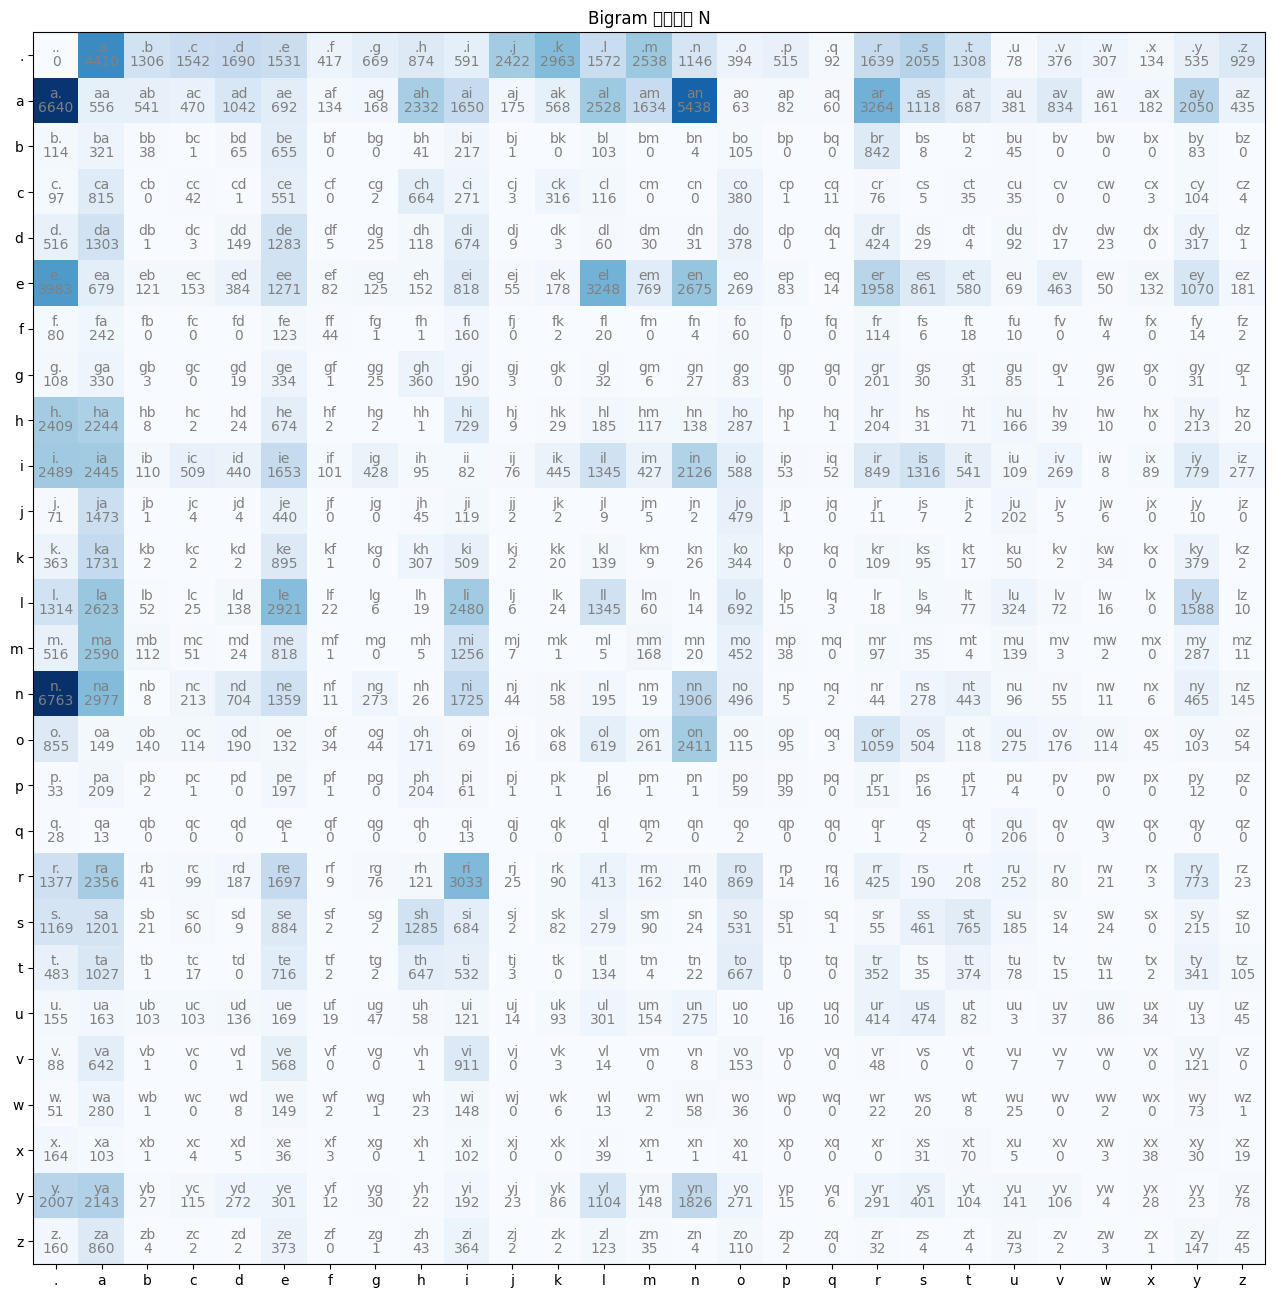

In [15]:
fig, ax = plt.subplots(figsize=(16, 16))
ax.imshow(N, cmap="Blues")

for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        ax.text(j, i, chstr, ha="center", va="bottom", color="gray")
        ax.text(j, i, int(N[i, j]), ha="center", va="top", color="gray")

ax.set_xticks(range(27))
ax.set_yticks(range(27))
ax.set_xticklabels([itos[i] for i in range(27)])
ax.set_yticklabels([itos[i] for i in range(27)])
ax.set_title("Bigram 计数矩阵 N")
plt.show()


# 3. 从计数模型到概率模型

计数矩阵 `N` 只能告诉我们“出现了多少次”，还不能直接用来采样。
想生成名字，我们需要把每一行计数变成概率分布。


## Step 15 - 先只归一化第 0 行（对应原 notebook cell 14）

**这个 cell 做什么**
- 把 `N[0]` 从整数计数转成浮点数。
- 再除以本行总和，让所有概率加起来等于 1。

**特殊函数说明**
- `.float()`：把整数 tensor 转成浮点 tensor。
- `.sum()`：把一个 tensor 中的元素求和。


In [16]:
p = N[0].float()
p = p / p.sum()
{"distribution_sum": float(p.sum()), "first_10_probs": p[:10]}


{'distribution_sum': 1.0,
 'first_10_probs': tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
         0.0184])}

## Step 16 - 根据概率随机抽一个字符（对应原 notebook cell 15-17）

**这个 cell 做什么**
- 用 `torch.Generator()` 创建一个受控随机数发生器。
- 用 `manual_seed(...)` 固定随机种子，保证结果可复现。
- 用 `torch.multinomial` 按概率分布采样。

**特殊函数说明**
- `torch.Generator()`：独立的随机数生成器对象。
- `.manual_seed(seed)`：设定随机种子。
- `torch.multinomial(p, num_samples=1, replacement=True, generator=g)`：
  按分布 `p` 抽样，返回被抽中的索引。


In [17]:
g = torch.Generator().manual_seed(2147483647)
ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
{"sampled_index": ix, "sampled_char": itos[ix]}


{'sampled_index': 3, 'sampled_char': 'c'}

## Step 17 - 用计数模型直接生成名字（对应原 notebook cell 25 的“未平滑版思路”）

**这个 cell 做什么**
- 从起始符 `'.'` 开始。
- 反复查看当前字符对应的那一行分布，采样出下一个字符。
- 一旦再次采到 `'.'`，就停止。

**为什么必要**
- 这就是字符级语言模型最朴素的采样过程。


In [18]:
g = torch.Generator().manual_seed(2147483647)

for _ in range(10):
    out = []
    ix = 0
    while True:
        p = N[ix].float()
        p = p / p.sum()
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print("".join(out))


cexze.
momasurailezitynn.
konimittain.
llayn.
ka.
da.
staiyaubrtthrigotai.
moliellavo.
ke.
teda.


## Step 18 - 为什么 `keepdim=True` 这么重要（对应原 notebook cell 19-24 的坑点）

**这个 cell 做什么**
- 比较 `N.sum(1)` 和 `N.sum(1, keepdim=True)` 的 shape。

**为什么必要**
- 后面我们会对整个矩阵按“行”归一化。
- 如果少了 `keepdim=True`，广播会把除法方向搞错，而且还不报错。

**特殊函数说明**
- `dim=1`：沿着列方向求和，得到每一行的总和。
- `keepdim=True`：求和之后保留被压缩掉的那一维，形状从 `(27,)` 变成 `(27, 1)`。


In [19]:
row_sums_bad = N.sum(1)
row_sums_good = N.sum(1, keepdim=True)

{
    "N_shape": tuple(N.shape),
    "row_sums_bad_shape": tuple(row_sums_bad.shape),
    "row_sums_good_shape": tuple(row_sums_good.shape),
}


{'N_shape': (27, 27),
 'row_sums_bad_shape': (27,),
 'row_sums_good_shape': (27, 1)}

## Step 19 - 演示“错误归一化”真的会静默出错

**这个 cell 做什么**
- 故意写一版错的：`N.float() / N.sum(1)`。
- 然后检查它是不是按行归一化成功。

**结果该怎么看**
- 如果是正确的按行归一化，那么每一行的和都应该接近 1。
- 这里你会发现不是这样，说明广播方向错了。


In [20]:
P_wrong = N.float() / N.sum(1)
{
    "wrong_row0_sum": float(P_wrong[0].sum()),
    "wrong_col0_sum": float(P_wrong[:, 0].sum()),
}


{'wrong_row0_sum': 7.022482872009277, 'wrong_col0_sum': 1.0}

## Step 20 - 正确做法：先加 1 平滑，再按行归一化（对应原 notebook cell 24）

**这个 cell 做什么**
- 对每个计数先加 1，做 Laplace smoothing。
- 再按行归一化，得到完整概率矩阵 `P`。

**为什么要加 1**
- 如果某个 bigram 从没在训练数据里出现，它的计数就是 0。
- 概率为 0 会导致后面 `log(0)` 变成负无穷，训练和评估都不方便。


In [21]:
P = (N + 1).float()
P = P / P.sum(1, keepdim=True)

{"P_shape": tuple(P.shape), "row0_sum": float(P[0].sum()), "row0_first_10": P[0, :10]}


{'P_shape': (27, 27),
 'row0_sum': 1.0,
 'row0_first_10': tensor([3.1192e-05, 1.3759e-01, 4.0767e-02, 4.8129e-02, 5.2745e-02, 4.7785e-02,
         1.3038e-02, 2.0898e-02, 2.7293e-02, 1.8465e-02])}

## Step 21 - 用平滑后的概率矩阵采样（对应原 notebook cell 25）

**这个 cell 做什么**
- 和前面的采样逻辑一样。
- 区别是现在用的是平滑后的 `P`，不是原始计数 `N`。


In [22]:
g = torch.Generator().manual_seed(2147483647)

for _ in range(10):
    out = []
    ix = 0
    while True:
        p = P[ix]
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print("".join(out))


cexze.
momasurailezitynn.
konimittain.
llayn.
ka.
da.
staiyaubrtthrigotai.
moliellavo.
ke.
teda.


# 4. 模型评估：likelihood、log likelihood、negative log likelihood

现在我们已经会“生成”名字了，但还不知道模型好不好。
评估思路是：训练数据中的每个真实 bigram，模型给它的概率应该尽量大。


## Step 22 - 先把目标说清楚（对应原 notebook cell 26）

我们想最大化训练数据的 **likelihood**。

对整份数据来说：

$$
\mathcal{L} = \prod p(\text{真实下一个字符} \mid \text{当前字符})
$$

但很多小概率连乘会非常小，所以通常改成求和更稳定的 **log likelihood**：

$$
\log \mathcal{L} = \sum \log p(\text{真实下一个字符} \mid \text{当前字符})
$$

训练里又习惯做最小化，因此再取负号，得到 **negative log likelihood**：

$$
\text{NLL} = -\log \mathcal{L}
$$

再除以样本数，就是平均负对数似然，也就是我们常说的 loss。


## Step 23 - 对整份训练数据计算 NLL（对应原 notebook cell 27）

**这个 cell 做什么**
- 遍历所有真实 bigram。
- 从 `P[ix1, ix2]` 取出模型给真实下一个字符的概率。
- 对它取对数并累加。

**特殊函数说明**
- `torch.log(x)`：计算自然对数。


In [23]:
log_likelihood = 0.0
n = 0

for w in words:
    chs = ["."] + list(w) + ["."]
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n += 1

nll = -log_likelihood
{"log_likelihood": float(log_likelihood), "nll": float(nll), "avg_nll": float(nll / n)}


{'log_likelihood': -559951.5625,
 'nll': 559951.5625,
 'avg_nll': 2.4543561935424805}

## Step 24 - 把单个名字的 NLL 展开看（官方 notebook 这一步是注释版，这里展开给你看）

**这个 cell 做什么**
- 只看一个名字。
- 把每个 bigram 的概率和 log probability 打印出来。

**为什么必要**
- 这样你可以把“公式”落到具体例子上。


In [24]:
sample_word = words[0]
chs = ["."] + list(sample_word) + ["."]

for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    prob = P[ix1, ix2]
    logprob = torch.log(prob)
    print(f"{ch1}{ch2}: prob={prob.item():.6f}, logprob={logprob.item():.6f}")


.e: prob=0.047785, logprob=-3.041035
em: prob=0.037653, logprob=-3.279348
mm: prob=0.025341, logprob=-3.675327
ma: prob=0.388514, logprob=-0.945426
a.: prob=0.195830, logprob=-1.630506


# 5. 神经网络版本的 bigram 模型

这一部分是官方 notebook 的核心转折点：

前面我们把 bigram 写成了“计数表 + 概率矩阵”，
现在要把同一件事写成“输入 one-hot 向量，乘上权重矩阵 `W`，输出下一字符分布”的神经网络。


## Step 25 - 先只用一个单词构造训练样本（对应原 notebook cell 28）

**这个 cell 做什么**
- 从一个名字里构造训练集 `(xs, ys)`。
- `xs` 存前一个字符索引，`ys` 存真实下一个字符索引。

**为什么先只用一个单词**
- 先把 shape 和数据流看懂，再扩展到整份数据。


In [25]:
xs, ys = [], []

for w in words[:1]:
    chs = ["."] + list(w) + ["."]
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        print(ch1, ch2)
        xs.append(ix1)
        ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)


. e
e m
m m
m a
a .


## Step 26 - 看输入索引 `xs`（对应原 notebook cell 29）

**这个 cell 做什么**
- `xs` 是每个 bigram 的前一个字符编号。


In [26]:
xs


tensor([ 0,  5, 13, 13,  1])

## Step 27 - 看标签索引 `ys`（对应原 notebook cell 30）

**这个 cell 做什么**
- `ys` 是每个 bigram 的真实下一个字符编号。


In [27]:
ys


tensor([ 5, 13, 13,  1,  0])

## Step 28 - 把索引变成 one-hot 编码（对应原 notebook cell 31）

**这个 cell 做什么**
- 把整数索引 `xs` 转成 one-hot 向量。

**one-hot 是什么**
- 长度为 27。
- 只有当前位置是 1，其余都是 0。

**为什么必要**
- 神经网络输入通常是数值向量。
- 这里 one-hot 的作用是“告诉模型当前字符是哪一个”。

**特殊函数说明**
- `torch.nn.functional.one_hot(xs, num_classes=27)`：把整数索引转成 one-hot。


In [28]:
import torch.nn.functional as F

xenc = F.one_hot(xs, num_classes=27).float()
xenc


tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.]])

## Step 29 - 看看 one-hot 的 shape 和 dtype（对应原 notebook cell 32、34）

**这个 cell 做什么**
- 输出 `xenc.shape` 和 `xenc.dtype`。

**shape 该怎么读**
- 行数 = 样本数
- 列数 = 字符类别数 27


In [29]:
{"shape": tuple(xenc.shape), "dtype": str(xenc.dtype)}


{'shape': (5, 27), 'dtype': 'torch.float32'}

## Step 30 - 把 one-hot 当图片看（对应原 notebook cell 33）

**这个 cell 做什么**
- 用热力图显示 `xenc`。
- 每一行恰好只有一个位置是亮的。


/Users/wangzhijie/.pyenv/versions/3.9.1/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/wangzhijie/.pyenv/versions/3.9.1/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/wangzhijie/.pyenv/versions/3.9.1/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 32534 (\N{CJK UNIFIED IDEOGRAPH-7F16}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/wangzhijie/.pyenv/versions/3.9.1/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 21495 (\N{CJK UNIFIED IDEOGRAPH-53F7}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/wangzhijie/.pyenv/versions/3.9.1/lib/python3.9/site-packa

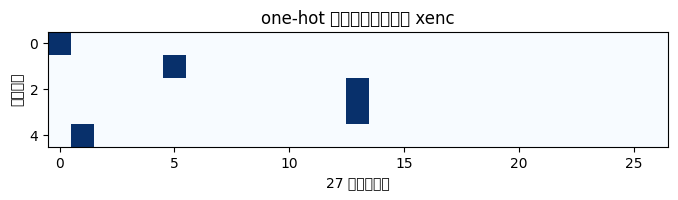

In [30]:
plt.figure(figsize=(8, 3))
plt.imshow(xenc, cmap="Blues")
plt.title("one-hot 编码后的输入矩阵 xenc")
plt.xlabel("27 个可能字符")
plt.ylabel("样本编号")
plt.show()


## Step 31 - 先做一个非常小的矩阵乘法例子（对应原 notebook cell 35）

**这个 cell 做什么**
- 先让 `W` 只有一列。
- 看 `xenc @ W` 会得到什么。

**特殊函数说明**
- `@`：矩阵乘法运算符。

**shape 推导**
- `(5, 27) @ (27, 1) -> (5, 1)`


In [31]:
g = torch.Generator().manual_seed(2147483647)
W_small = torch.randn((27, 1), generator=g)
xenc @ W_small


tensor([[ 1.5674],
        [-0.0296],
        [ 0.0380],
        [ 0.0380],
        [-0.2373]])

## Step 32 - 真正的神经网络权重应该是 `(27, 27)`（对应原 notebook cell 40、44）

**这个 cell 做什么**
- 初始化完整权重矩阵 `W`。
- 每个输入字符都要输出 27 个“下一个字符”的打分。

**shape 推导**
- `(样本数, 27) @ (27, 27) -> (样本数, 27)`


In [32]:
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g)
{"W_shape": tuple(W.shape), "W_mean": float(W.mean()), "W_std": float(W.std())}


{'W_shape': (27, 27),
 'W_mean': 0.016728941351175308,
 'W_std': 0.9836476445198059}

## Step 33 - 从输入到 logits（对应原 notebook cell 36、45 的第一行）

**这个 cell 做什么**
- 计算 `logits = xenc @ W`。

**logits 是什么**
- 还不是概率。
- 可以理解成“每个下一个字符的原始打分”。


In [33]:
logits = xenc @ W
logits


tensor([[ 1.5674e+00, -2.3729e-01, -2.7385e-02, -1.1008e+00,  2.8588e-01,
         -2.9644e-02, -1.5471e+00,  6.0489e-01,  7.9136e-02,  9.0462e-01,
         -4.7125e-01,  7.8682e-01, -3.2844e-01, -4.3297e-01,  1.3729e+00,
          2.9334e+00,  1.5618e+00, -1.6261e+00,  6.7716e-01, -8.4040e-01,
          9.8488e-01, -1.4837e-01, -1.4795e+00,  4.4830e-01, -7.0731e-02,
          2.4968e+00,  2.4448e+00],
        [ 4.7236e-01,  1.4830e+00,  3.1748e-01,  1.0588e+00,  2.3982e+00,
          4.6827e-01, -6.5650e-01,  6.1662e-01, -6.2198e-01,  5.1007e-01,
          1.3563e+00,  2.3445e-01, -4.5585e-01, -1.3132e-03, -5.1161e-01,
          5.5570e-01,  4.7458e-01, -1.3867e+00,  1.6229e+00,  1.7197e-01,
          9.8846e-01,  5.0657e-01,  1.0198e+00, -1.9062e+00, -4.2753e-01,
         -2.1259e+00,  9.6041e-01],
        [ 1.9359e-01,  1.0532e+00,  6.3393e-01,  2.5786e-01,  9.6408e-01,
         -2.4855e-01,  2.4756e-02, -3.0404e-02,  1.5622e+00, -4.4852e-01,
         -1.2345e+00,  1.1220e+00, -6.73

## Step 34 - 从 logits 到概率：`exp` 再归一化（对应原 notebook cell 36、45）

**这个 cell 做什么**
- `counts = logits.exp()`
- `probs = counts / counts.sum(1, keepdim=True)`

**为什么这样做**
- `exp()` 把任意实数变成正数。
- 再按行归一化，就得到合法概率分布。

**特殊函数说明**
- `.exp()`：逐元素做指数运算。
- `.sum(1, keepdim=True)`：每行求和，同时保留列维度，方便广播。
- 这两步合在一起就是 softmax 的核心。


In [34]:
counts = logits.exp()
probs = counts / counts.sum(1, keepdim=True)
probs


tensor([[0.0607, 0.0100, 0.0123, 0.0042, 0.0168, 0.0123, 0.0027, 0.0232, 0.0137,
         0.0313, 0.0079, 0.0278, 0.0091, 0.0082, 0.0500, 0.2378, 0.0603, 0.0025,
         0.0249, 0.0055, 0.0339, 0.0109, 0.0029, 0.0198, 0.0118, 0.1537, 0.1459],
        [0.0290, 0.0796, 0.0248, 0.0521, 0.1989, 0.0289, 0.0094, 0.0335, 0.0097,
         0.0301, 0.0702, 0.0228, 0.0115, 0.0181, 0.0108, 0.0315, 0.0291, 0.0045,
         0.0916, 0.0215, 0.0486, 0.0300, 0.0501, 0.0027, 0.0118, 0.0022, 0.0472],
        [0.0312, 0.0737, 0.0484, 0.0333, 0.0674, 0.0200, 0.0263, 0.0249, 0.1226,
         0.0164, 0.0075, 0.0789, 0.0131, 0.0267, 0.0147, 0.0112, 0.0585, 0.0121,
         0.0650, 0.0058, 0.0208, 0.0078, 0.0133, 0.0203, 0.1204, 0.0469, 0.0126],
        [0.0312, 0.0737, 0.0484, 0.0333, 0.0674, 0.0200, 0.0263, 0.0249, 0.1226,
         0.0164, 0.0075, 0.0789, 0.0131, 0.0267, 0.0147, 0.0112, 0.0585, 0.0121,
         0.0650, 0.0058, 0.0208, 0.0078, 0.0133, 0.0203, 0.1204, 0.0469, 0.0126],
        [0.0150, 0.0086,

## Step 35 - 检查输出概率是不是合法（对应原 notebook cell 37-39、46）

**这个 cell 做什么**
- 看第一行概率。
- 看整张概率表的 shape。
- 验证每行和是不是 1。


In [35]:
{
    "probs_shape": tuple(probs.shape),
    "row0": probs[0],
    "row0_sum": float(probs[0].sum()),
}


{'probs_shape': (5, 27),
 'row0': tensor([0.0607, 0.0100, 0.0123, 0.0042, 0.0168, 0.0123, 0.0027, 0.0232, 0.0137,
         0.0313, 0.0079, 0.0278, 0.0091, 0.0082, 0.0500, 0.2378, 0.0603, 0.0025,
         0.0249, 0.0055, 0.0339, 0.0109, 0.0029, 0.0198, 0.0118, 0.1537, 0.1459]),
 'row0_sum': 1.0000001192092896}

## Step 36 - 手工计算前 5 个样本的 NLL（对应原 notebook cell 47）

**这个 cell 做什么**
- 对每个样本，拿出模型分给真实标签 `y` 的概率。
- 对它取 `log`，再取负号，得到单样本 NLL。

**为什么必要**
- 这是把 softmax 输出和 loss 函数连接起来的关键一步。

**特殊函数说明**
- `.item()`：把单元素 tensor 转成普通 Python 标量，方便打印。


In [36]:
nlls = torch.zeros(5)

for i in range(5):
    x = xs[i].item()
    y = ys[i].item()
    print("--------")
    print(f"bigram example {i + 1}: {itos[x]}{itos[y]} (indexes {x}, {y})")
    print("input to the neural net:", x)
    print("output probabilities from the neural net:", probs[i])
    print("label (actual next character):", y)
    p = probs[i, y]
    print("probability assigned by the net to the correct character:", p.item())
    logp = torch.log(p)
    print("log likelihood:", logp.item())
    nll = -logp
    print("negative log likelihood:", nll.item())
    nlls[i] = nll

print("=========")
print("average negative log likelihood, i.e. loss =", nlls.mean().item())


--------
bigram example 1: .e (indexes 0, 5)
input to the neural net: 0
output probabilities from the neural net: tensor([0.0607, 0.0100, 0.0123, 0.0042, 0.0168, 0.0123, 0.0027, 0.0232, 0.0137,
        0.0313, 0.0079, 0.0278, 0.0091, 0.0082, 0.0500, 0.2378, 0.0603, 0.0025,
        0.0249, 0.0055, 0.0339, 0.0109, 0.0029, 0.0198, 0.0118, 0.1537, 0.1459])
label (actual next character): 5
probability assigned by the net to the correct character: 0.012286253273487091
log likelihood: -4.3992743492126465
negative log likelihood: 4.3992743492126465
--------
bigram example 2: em (indexes 5, 13)
input to the neural net: 5
output probabilities from the neural net: tensor([0.0290, 0.0796, 0.0248, 0.0521, 0.1989, 0.0289, 0.0094, 0.0335, 0.0097,
        0.0301, 0.0702, 0.0228, 0.0115, 0.0181, 0.0108, 0.0315, 0.0291, 0.0045,
        0.0916, 0.0215, 0.0486, 0.0300, 0.0501, 0.0027, 0.0118, 0.0022, 0.0472])
label (actual next character): 13
probability assigned by the net to the correct character: 0.018

# 6. 自动求导和单步优化

到这里为止，我们已经能前向算出 loss。
下一步就是让 `W` 真正朝着“更小 loss”的方向更新。


## Step 37 - 初始化可求导的权重（对应原 notebook cell 51）

**这个 cell 做什么**
- 重新初始化一份 `W`，并设置 `requires_grad=True`。

**特殊函数说明**
- `requires_grad=True`：告诉 PyTorch 后面需要为这个 tensor 记录计算图并求梯度。


In [37]:
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)
W.shape


torch.Size([27, 27])

## Step 38 - 重新做一遍 forward pass（对应原 notebook cell 52）

**这个 cell 做什么**
- 用前面那 5 个样本重新计算 `probs` 和 `loss`。
- 这里的 `loss` 就是平均负对数似然。

**特殊函数说明**
- `torch.arange(5)`：生成 `[0, 1, 2, 3, 4]`。
- `probs[torch.arange(5), ys]`：高级索引，一次取出每一行对应标签列的概率。
- `.mean()`：求平均值。


In [38]:
xenc = F.one_hot(xs, num_classes=27).float()
logits = xenc @ W
counts = logits.exp()
probs = counts / counts.sum(1, keepdim=True)
loss = -probs[torch.arange(5), ys].log().mean()
loss


tensor(3.7693, grad_fn=<NegBackward0>)

## Step 39 - 查看当前 loss（对应原 notebook cell 53）

这里单独取 `.item()`，只是为了输出更干净。


In [39]:
loss.item()


3.7693049907684326

## Step 40 - 反向传播拿到梯度（对应原 notebook cell 54）

**这个 cell 做什么**
- 先把旧梯度清掉。
- 再执行 `loss.backward()`。

**为什么先清梯度**
- PyTorch 默认会把梯度累加到 `.grad` 上。
- 所以每次反向传播前都要先清掉旧值。

**特殊函数说明**
- `W.grad = None`：把梯度置空，这是 PyTorch 中常见的清梯度写法。
- `loss.backward()`：根据计算图自动求出 `loss` 对 `W` 的梯度。


In [40]:
W.grad = None
loss.backward()
{"grad_shape": tuple(W.grad.shape), "grad_mean_abs": float(W.grad.abs().mean())}


{'grad_shape': (27, 27), 'grad_mean_abs': 0.002608476672321558}

## Step 41 - 做一次梯度下降更新（对应原 notebook cell 55）

**这个 cell 做什么**
- 用 `W = W - lr * grad` 的思路更新参数。
- 然后重新算一次 loss，对比更新前后有没有下降。


In [41]:
loss_before = loss.item()
W.data += -0.1 * W.grad

xenc = F.one_hot(xs, num_classes=27).float()
logits = xenc @ W
counts = logits.exp()
probs = counts / counts.sum(1, keepdim=True)
loss_after = -probs[torch.arange(5), ys].log().mean().item()

{"loss_before": loss_before, "loss_after": loss_after}


{'loss_before': 3.7693049907684326, 'loss_after': 3.7492129802703857}

# 7. 用整份数据真正训练 bigram 网络

前面只是拿 5 个样本演示自动求导。
现在要把整份数据都放进来，做真正的训练。


## Step 42 - 用全部名字构造训练集（对应原 notebook cell 57 的前半部分）

**这个 cell 做什么**
- 遍历所有名字，构造完整的 `xs` 和 `ys`。
- 统计总样本数 `num`。


In [42]:
xs, ys = [], []
for w in words:
    chs = ["."] + list(w) + ["."]
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()

{"num_examples": num, "xs_shape": tuple(xs.shape), "ys_shape": tuple(ys.shape)}


{'num_examples': 228146, 'xs_shape': (228146,), 'ys_shape': (228146,)}

## Step 43 - 初始化整份数据训练用的网络（对应原 notebook cell 57 的后半部分）

**这个 cell 做什么**
- 重新初始化 `W`。
- 这次它会在完整训练循环里被持续更新。


In [43]:
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)
W.shape


torch.Size([27, 27])

## Step 44 - 开始真正的梯度下降（对应原 notebook cell 58）

**这个 cell 做什么**
- 每轮都执行 forward、loss、backward、update。
- loss 里额外加上 `0.01 * (W**2).mean()`，这是 L2 正则化。

**为什么加正则项**
- 防止权重变得过大。
- 也可以看作对模型复杂度的一点约束。

**特殊函数说明**
- `(W**2).mean()`：先平方再求平均。
- 训练循环里的 `for k in range(...)`：重复多次更新参数。


In [44]:
losses = []

for k in range(100):
    xenc = F.one_hot(xs, num_classes=27).float()
    logits = xenc @ W
    counts = logits.exp()
    probs = counts / counts.sum(1, keepdim=True)
    loss = -probs[torch.arange(num), ys].log().mean() + 0.01 * (W**2).mean()
    losses.append(loss.item())

    W.grad = None
    loss.backward()
    W.data += -50 * W.grad

{"first_5_losses": losses[:5], "last_5_losses": losses[-5:]}


{'first_5_losses': [3.768618583679199,
  3.3788065910339355,
  3.161090850830078,
  3.027186155319214,
  2.9344840049743652],
 'last_5_losses': [2.4908623695373535,
  2.4906723499298096,
  2.4904870986938477,
  2.4903066158294678,
  2.4901301860809326]}

## Step 45 - 画出 loss 曲线，确认训练确实在收敛

**这个 cell 做什么**
- 把训练过程中的 loss 画出来。


/Users/wangzhijie/.pyenv/versions/3.9.1/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/wangzhijie/.pyenv/versions/3.9.1/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/wangzhijie/.pyenv/versions/3.9.1/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 36807 (\N{CJK UNIFIED IDEOGRAPH-8FC7}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/wangzhijie/.pyenv/versions/3.9.1/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 31243 (\N{CJK UNIFIED IDEOGRAPH-7A0B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/wangzhijie/.pyenv/versions/3.9.1/lib/python3.9/site-packa

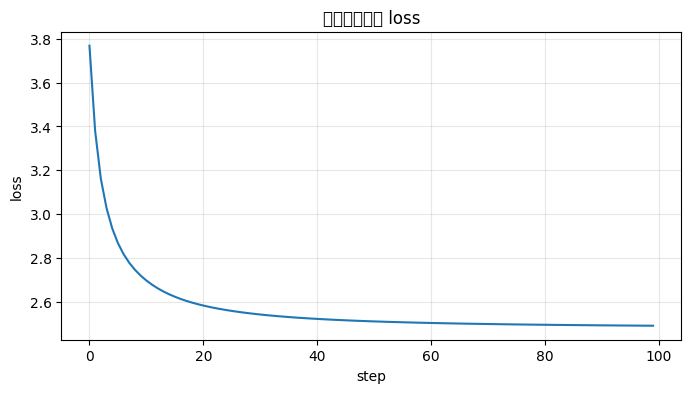

In [45]:
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.title("训练过程中的 loss")
plt.xlabel("step")
plt.ylabel("loss")
plt.grid(alpha=0.3)
plt.show()


## Step 46 - 训练完成后，用神经网络模型采样（对应原 notebook cell 59）

**这个 cell 做什么**
- 从起始符 `'.'` 开始。
- 先把当前字符编号做 one-hot。
- 经由 `W` 计算下一字符概率，再采样。

**关键理解**
- 前面计数版是直接查 `P[ix]`。
- 现在神经网络版是现场算 `p = softmax(one_hot(ix) @ W)`。


In [46]:
g = torch.Generator().manual_seed(2147483647)

for _ in range(10):
    out = []
    ix = 0
    while True:
        xenc = F.one_hot(torch.tensor([ix]), num_classes=27).float()
        logits = xenc @ W
        counts = logits.exp()
        p = counts / counts.sum(1, keepdim=True)

        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print("".join(out))


cexze.
momasurailezityha.
konimittain.
llayn.
ka.
da.
staiyaubrtthrigotai.
moliellavo.
ke.
teda.


# 8. 计数版和神经网络版，其实在学同一件事

这是本 notebook 最重要的认知点：

- 计数版 bigram：直接从数据统计 `P(next | current)`。
- 神经网络版 bigram：通过优化 `W`，间接学出 `P(next | current)`。

两者只是参数化方式不同，本质目标完全一样。


## Step 47 - 对比“起始符 `.` 的下一字符分布”（教学补充）

**这个 cell 做什么**
- 从统计模型 `P` 取出第 0 行。
- 从神经网络 `W` 现场算出“输入 `.` 时”的概率分布。
- 各自取 top-5 看看最可能的首字母是否接近。


In [47]:
p_count = P[0]

xenc0 = F.one_hot(torch.tensor([0]), num_classes=27).float()
logits0 = xenc0 @ W
counts0 = logits0.exp()
p_nn = (counts0 / counts0.sum(1, keepdim=True)).squeeze(0)

topk_count = torch.topk(p_count, k=5)
topk_nn = torch.topk(p_nn, k=5)

{
    "count_model_top5": [(itos[i.item()], float(v)) for v, i in zip(topk_count.values, topk_count.indices)],
    "nn_model_top5": [(itos[i.item()], float(v)) for v, i in zip(topk_nn.values, topk_nn.indices)],
}


{'count_model_top5': [('a', 0.13758577406406403),
  ('k', 0.09245165437459946),
  ('m', 0.07919526100158691),
  ('j', 0.07557704299688339),
  ('s', 0.06412975490093231)],
 'nn_model_top5': [('a', 0.13727538287639618),
  ('k', 0.09218063950538635),
  ('m', 0.07894322276115417),
  ('j', 0.07533106952905655),
  ('s', 0.0639059767127037)]}

## Step 48 - 最后做一个总结

你在这份 notebook 里已经完整走通了：

1. 从原始字符串数据提取 bigram。
2. 用字典和矩阵两种方式表示 bigram 计数。
3. 从计数得到概率，并用概率生成新名字。
4. 用平均负对数似然评估模型。
5. 用 one-hot + 矩阵乘法 + softmax 把同一件事重写成神经网络。
6. 用 `requires_grad`、`loss.backward()` 和梯度下降训练参数。

如果你能把这几段自己默写一遍，`makemore part 1` 的核心就已经吃透了。
